# AI Adoption & Developer Productivity

This notebook presents the analysis from an ongoing study asking: **does AI coding tool adoption increase developer productivity?**

Two phases:
- **Phase 1** — country-level panel regression linking AI readiness to GitHub activity metrics (2022–2024)
- **Phase 2** — account-level binary classifier to identify AI coding tool users from behavioural signals

Data sources: [GH Archive](https://www.gharchive.org/), [GitHub REST API](https://docs.github.com/en/rest), [Oxford Insights AI Readiness Index](https://oxfordinsights.com/ai-readiness/ai-readiness-index/)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
import json
warnings.filterwarnings("ignore")

# sklearn for classifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import permutation_importance

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": plt.cycler(color=["#2196F3","#FF5722","#4CAF50","#9C27B0","#FF9800"]),
    "font.size": 11,
})

DATA = "/home/andreasclaw/projects/ai_productivity_analysis/data"
print("Data dir:", DATA)
print("Files:", [f for f in os.listdir(DATA) if f.endswith((".csv",".json",".txt")) and not f.startswith("gharchive")])

Data dir: /home/andreasclaw/projects/ai_productivity_analysis/data
Files: ['full_positive_progress.json', 'regression_results.txt', 'full_claude_markers.csv', 'classifier_full_raw.json', 'full_positive_logins.csv', 'github_panel_raw.json', 'test_negative_candidates.csv', 'classifier_positive_logins.csv', 'classifier_test_raw.json', 'github_panel_flat.csv', 'classifier_negative_logins.csv', 'full_negative_status.csv', 'test_positive_progress.json', 'panel_dataset.csv', 'classifier_sample_raw.json', 'classifier_full_features.csv', 'github_productivity_results.json', 'classifier_test_features.csv', 'test_claude_markers.csv', 'test_positive_logins.csv', 'classifier_sample_features.csv', 'full_negative_candidates.csv']


---
## Phase 1: Country Panel

We scraped 9 quarterly GH Archive windows (Q4 2022 – Q4 2024), 500 developers per window, located ~26% by country. Merged with the Oxford Insights Government AI Readiness Index and ran OLS with country + year fixed effects.

In [2]:
panel = pd.read_csv(f'{DATA}/panel_dataset.csv')
print(f'Panel: {panel.shape[0]} obs × {panel.shape[1]} cols')
print(f'Countries: {panel["country"].nunique()}   Years: {sorted(panel["year"].unique())}')
panel.head()

Panel: 88 obs × 9 cols
Countries: 51   Years: [np.int64(2022), np.int64(2024)]


,country,year,ai_readiness_score,commits_per_dev,prs_per_dev,creates_per_dev,comments_per_dev,total_events_per_dev,n_developers
0,AE,2022,68.544019,2.0,0.0,0.0,0.0,2.0,1
1,AE,2024,70.423033,8.0,1.0,0.0,2.0,11.0,1
2,AR,2022,57.386817,1.0,0.0,0.0,0.0,1.0,1
3,AR,2024,57.724174,6.0,0.0,1.0,0.0,7.0,1
4,AT,2022,71.490811,1.0,0.0,0.0,0.0,1.0,1


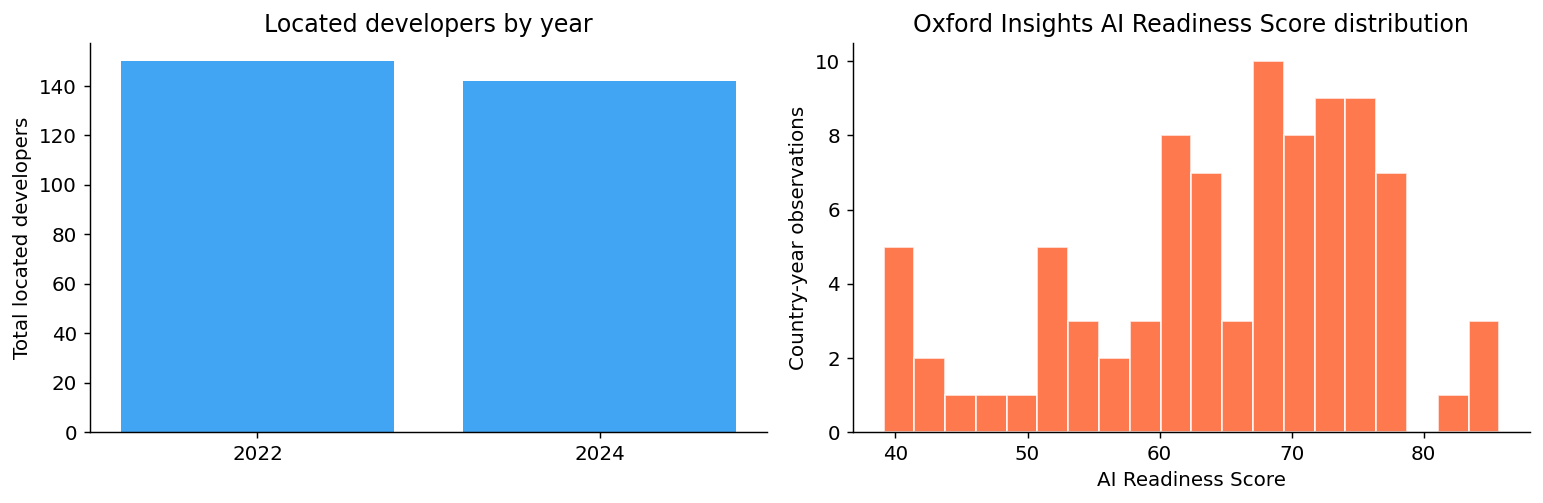

In [3]:
# Distribution of developer counts per country-year
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Developer coverage by year
year_groups = panel.groupby('year')['n_developers'].sum()
axes[0].bar(year_groups.index.astype(str), year_groups.values, color='#2196F3', alpha=0.85)
axes[0].set_title('Located developers by year')
axes[0].set_ylabel('Total located developers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# AI readiness score distribution
axes[1].hist(panel['ai_readiness_score'].dropna(), bins=20, color='#FF5722', alpha=0.8, edgecolor='white')
axes[1].set_title('Oxford Insights AI Readiness Score distribution')
axes[1].set_xlabel('AI Readiness Score')
axes[1].set_ylabel('Country-year observations')

plt.tight_layout()
plt.savefig('../data/figures/panel_overview.png', bbox_inches='tight')
plt.show()

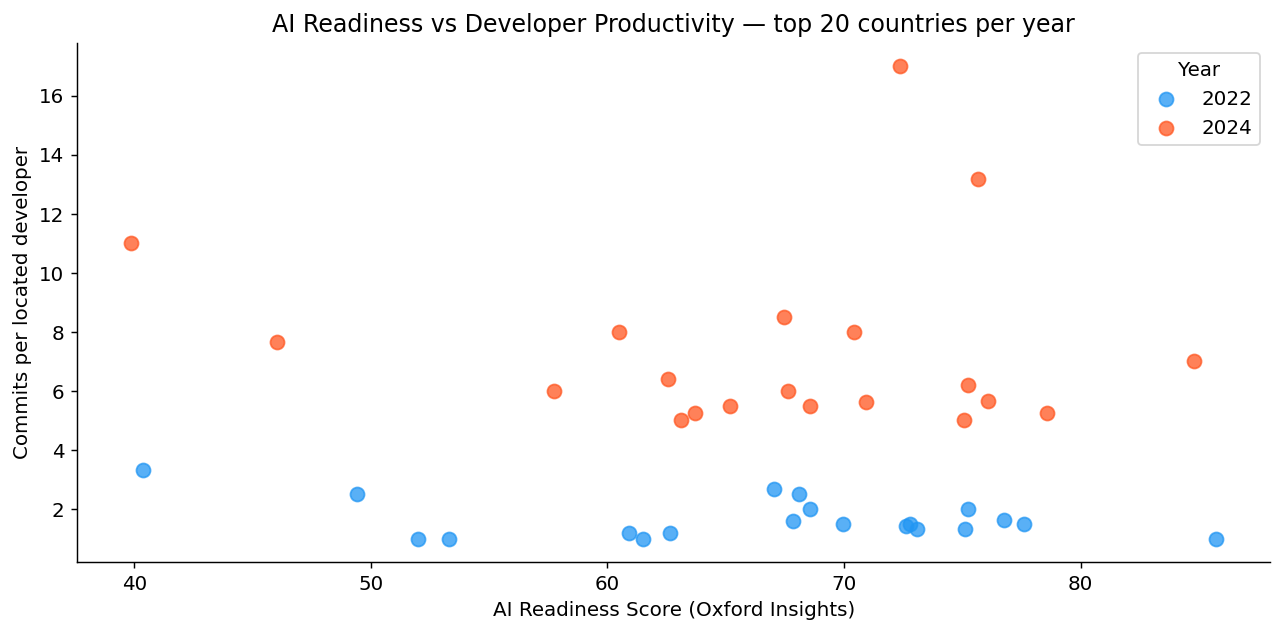

Note: y-axis is commits_per_dev; outliers reflect thin country samples


In [4]:
# Commits per developer by year — the main productivity signal
fig, ax = plt.subplots(figsize=(10, 5))

for year, grp in panel.groupby('year'):
    grp_sorted = grp.sort_values('commits_per_dev', ascending=False).head(20)
    ax.scatter(grp_sorted['ai_readiness_score'], grp_sorted['commits_per_dev'],
               label=str(year), alpha=0.75, s=60)

ax.set_xlabel('AI Readiness Score (Oxford Insights)')
ax.set_ylabel('Commits per located developer')
ax.set_title('AI Readiness vs Developer Productivity — top 20 countries per year')
ax.legend(title='Year')
plt.tight_layout()
plt.show()
print('Note: y-axis is commits_per_dev; outliers reflect thin country samples')

In [5]:
# Year-over-year productivity shift — the real signal in Phase 1
prod_cols = [c for c in panel.columns if 'per_dev' in c or 'per_located' in c]
print('Productivity columns:', prod_cols)

commits_by_year = panel.groupby('year')['commits_per_dev'].agg(['median', 'mean']).round(2)
print('\nCommits per developer by year:')
print(commits_by_year)

Productivity columns: ['commits_per_dev', 'prs_per_dev', 'creates_per_dev', 'comments_per_dev', 'total_events_per_dev']

Commits per developer by year:
      median  mean
year              
2022     1.0  1.18
2024     4.0  4.56


In [6]:
# Regression results
with open('../data/regression_results.txt') as f:
    results = f.read()
print(results[:3000])

OLS REGRESSION RESULTS
Dependent variable: log(total_events_per_dev)
Independent variable: ai_readiness_score
Fixed effects: country dummies (C(country))
N observations: 88
N countries: 51

                               OLS Regression Results                               
Dep. Variable:     log_total_events_per_dev   R-squared:                       0.326
Model:                                  OLS   Adj. R-squared:                 -0.629
Method:                       Least Squares   F-statistic:                    0.3415
Date:                      Wed, 25 Mar 2026   Prob (F-statistic):               1.00
Time:                              07:07:26   Log-Likelihood:                -90.501
No. Observations:                        88   AIC:                             285.0
Df Residuals:                            36   BIC:                             413.8
Df Model:                                51                                         
Covariance Type:                  nonrobust  

### Phase 1 Findings

- **88 country-year observations, 51 countries**
- OLS with country FE: `ai_readiness_score` coefficient = 0.115, p = 0.497 — **not significant**
- Real signal: 2024 productivity visibly higher than 2022 — but that's a time trend, not a cross-country effect
- **Root cause of null result:** Oxford Insights measures government AI *policy* readiness — infrastructure frameworks, national strategies. That's three steps removed from whether a developer opened Claude Code this morning.

**Fix:** build an account-level classifier to identify actual AI tool users, then use fraction-of-AI-users-per-country-quarter as the independent variable.

---
## Phase 2: Account-Level Classifier

Ground truth: GitHub Code Search for `CLAUDE.md` files + GH Archive scan for `Co-Authored-By: Claude` commit trailers.

Behavioural features (no label leakage — explicit markers excluded from features):
- Δ commit message length pre/post adoption
- Δ fraction of conventional commits
- Δ PR description completeness
- Δ test co-write rate
- Δ multiline commit fraction, burst patterns, inter-commit timing

In [7]:
# Smart data loader — uses best available feature set
# Priority: classifier_full_features.csv > classifier_test_features.csv

full_path = f"{DATA}/classifier_full_features.csv"
test_path = f"{DATA}/classifier_test_features.csv"

if os.path.exists(full_path):
    feats = pd.read_csv(full_path)
    data_source = "FULL RUN"
else:
    feats = pd.read_csv(test_path)
    data_source = "TEST RUN (full features pending)"

print(f"[{data_source}] Features: {feats.shape[0]} accounts x {feats.shape[1]} cols")
label_counts = dict(feats["label"].value_counts())
print(f"Labels: {label_counts}  (1=AI user, 0=control)")

# Scraper status
progress_path = f"{DATA}/full_positive_progress.json"
neg_status_path = f"{DATA}/full_negative_status.csv"
if os.path.exists(progress_path):
    with open(progress_path) as fh:
        n_pos_done = len(json.load(fh))
    print(f"Scraper status: {n_pos_done}/500 positives scraped")
if os.path.exists(neg_status_path):
    neg_df = pd.read_csv(neg_status_path)
    n_acc = int((neg_df["status"] == "accepted").sum())
    n_rej = int((neg_df["status"] == "rejected").sum())
    print(f"  Negatives: {n_acc} accepted, {n_rej} rejected ({len(neg_df)} evaluated)")

# Both-window accounts — valid for DiD
both = feats[(feats["pre_commit_count"] >= 10) & (feats["post_commit_count"] >= 10)].copy()
pos = both[both["label"] == 1]
neg = both[both["label"] == 0]
print(f"\nBoth-window: {len(both)} accounts ({len(pos)} AI users, {len(neg)} controls)")
feats.head()

[FULL RUN] Features: 235 accounts x 49 cols
Labels: {0: np.int64(202), 1: np.int64(33)}  (1=AI user, 0=control)
Scraper status: 500/500 positives scraped
  Negatives: 213 accepted, 1904 rejected (2117 evaluated)

Both-window: 235 accounts (33 AI users, 202 controls)


,login,label,discovery_method,marker_confidence,pre_commit_count,pre_mean_message_length,pre_active_weeks,pre_repos_touched,pre_mean_commits_per_active_week,pre_frac_multiline,...,delta_frac_multiline,delta_frac_conventional,delta_frac_mentions_test,delta_frac_has_bullets,delta_mean_inter_commit_hours,delta_frac_burst_commits,delta_sampled_test_cowrite_rate,delta_file_sample_count,delta_mean_pr_body_length,delta_frac_pr_has_body
0,risingtiger,1,code_search,low,14,20.50,6,3,2.33,0.000,...,0.005,0.900,0.000,0.0,-540.74,0.200,0.026,38,1566.00,1.000
1,GowayLee,1,code_search,low,11,32.18,2,1,5.50,0.091,...,0.008,0.312,0.000,0.0,-5.00,-0.282,0.091,20,51.60,0.500
2,mouloud240,1,code_search,low,17,25.82,2,3,8.50,0.118,...,0.046,0.000,0.075,0.0,247.32,0.014,0.500,11,25.78,0.222
3,JS1240,1,code_search,low,52,43.13,3,2,17.33,0.000,...,0.340,0.070,0.030,0.0,76.93,-0.016,-0.278,11,815.82,1.000
4,lgd-matlab,1,code_search,low,10,17.60,3,1,3.33,0.000,...,0.000,0.000,0.000,0.0,-210.42,0.187,0.000,40,0.00,0.000


In [8]:
# Key delta features — the heart of the DiD design
delta_cols = [
    ('delta_mean_message_length',      'Δ commit message length (chars)'),
    ('delta_frac_conventional',        'Δ conventional commit fraction'),
    ('delta_frac_pr_has_body',         'Δ PR has body fraction'),
    ('delta_sampled_test_cowrite_rate','Δ test co-write rate'),
    ('delta_frac_multiline',           'Δ multiline commit fraction'),
    ('delta_mean_pr_body_length',      'Δ PR body length (chars)'),
]

# Fall back to old column name if v2 column not present
delta_cols = [(c if c in both.columns else c.replace('sampled_test_cowrite_rate','test_cowrite_rate'), l)
              for c, l in delta_cols]
delta_cols = [(c, l) for c, l in delta_cols if c in both.columns]

pos = both[both['label'] == 1]
neg = both[both['label'] == 0]

print("{:<40} {:>12} {:>12} {:>8}".format("Feature", "AI users", "Controls", "Ratio"))
print('-' * 76)
for col, label in delta_cols:
    pm = pos[col].mean()
    nm = neg[col].mean()
    ratio = pm / nm if nm != 0 else float('inf')
    print("{:<40} {:>+12.2f} {:>+12.2f} {:>8.1f}x".format(label, pm, nm, ratio))

Feature                                      AI users     Controls    Ratio
----------------------------------------------------------------------------
Δ commit message length (chars)                +46.85        +6.64      7.1x
Δ conventional commit fraction                  +0.11        +0.03      3.3x
Δ PR has body fraction                          +0.09        +0.01      6.5x
Δ test co-write rate                            +0.01        -0.04     -0.3x
Δ multiline commit fraction                     +0.11        +0.02      5.3x
Δ PR body length (chars)                      -567.72       -17.00     33.4x


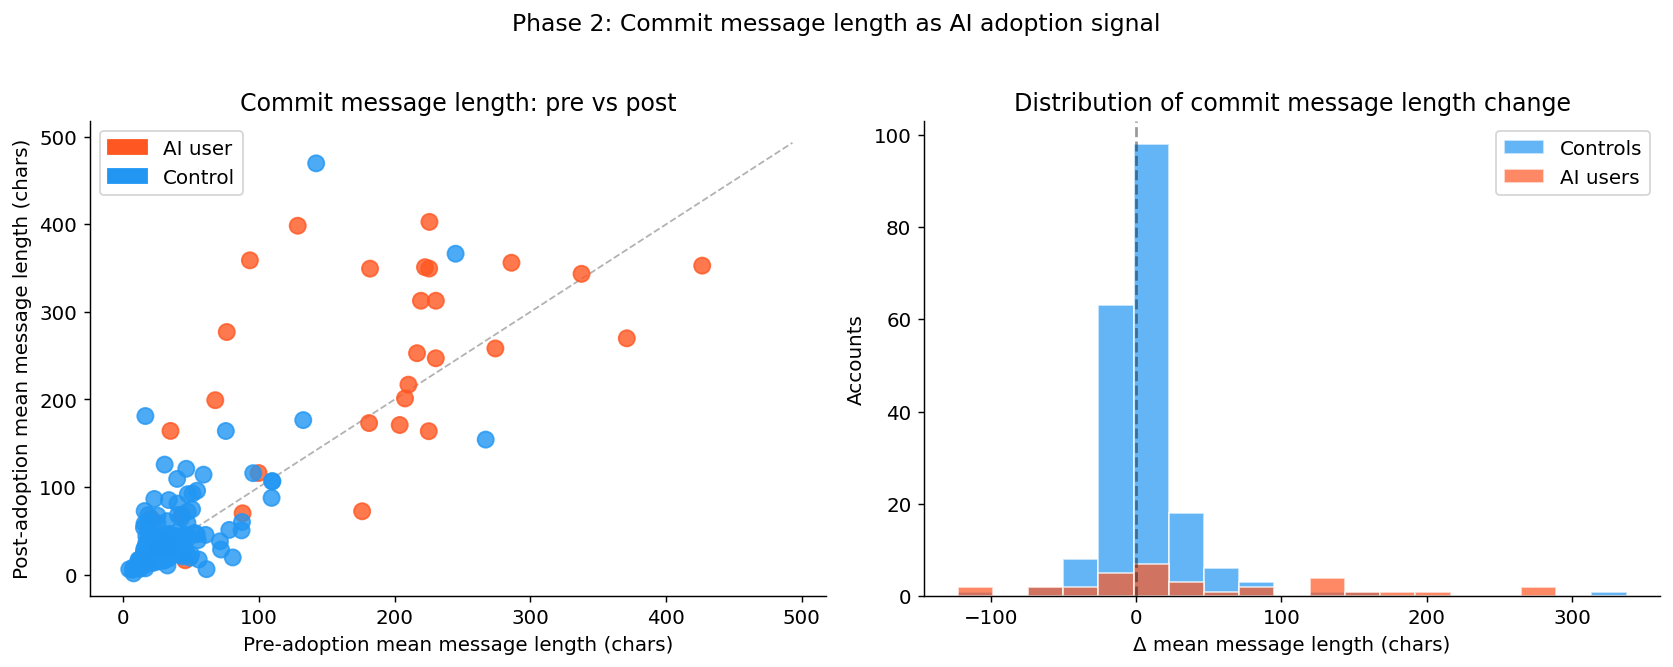

In [9]:
# Visualise the strongest signal: commit message length shift
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pre vs post message length by group
x = np.arange(len(both))
colors = ['#FF5722' if l == 1 else '#2196F3' for l in both['label']]
labels_str = ['AI user' if l == 1 else 'Control' for l in both['label']]

axes[0].scatter(both['pre_mean_message_length'], both['post_mean_message_length'],
                c=colors, alpha=0.8, s=80, zorder=3)
lim = max(both['pre_mean_message_length'].max(), both['post_mean_message_length'].max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'k--', alpha=0.3, linewidth=1)
axes[0].set_xlabel('Pre-adoption mean message length (chars)')
axes[0].set_ylabel('Post-adoption mean message length (chars)')
axes[0].set_title('Commit message length: pre vs post')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#FF5722', label='AI user'), Patch(color='#2196F3', label='Control')])

# Delta distribution
pos_deltas = pos['delta_mean_message_length'].values
neg_deltas = neg['delta_mean_message_length'].values
bins = np.linspace(
    min(pos_deltas.min(), neg_deltas.min()) - 10,
    max(pos_deltas.max(), neg_deltas.max()) + 10,
    20
)
axes[1].hist(neg_deltas, bins=bins, alpha=0.7, color='#2196F3', label='Controls', edgecolor='white')
axes[1].hist(pos_deltas, bins=bins, alpha=0.7, color='#FF5722', label='AI users', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.4)
axes[1].set_xlabel('Δ mean message length (chars)')
axes[1].set_ylabel('Accounts')
axes[1].set_title('Distribution of commit message length change')
axes[1].legend()

plt.suptitle('Phase 2: Commit message length as AI adoption signal', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/figures/phase2_message_length.png', bbox_inches='tight')
plt.show()

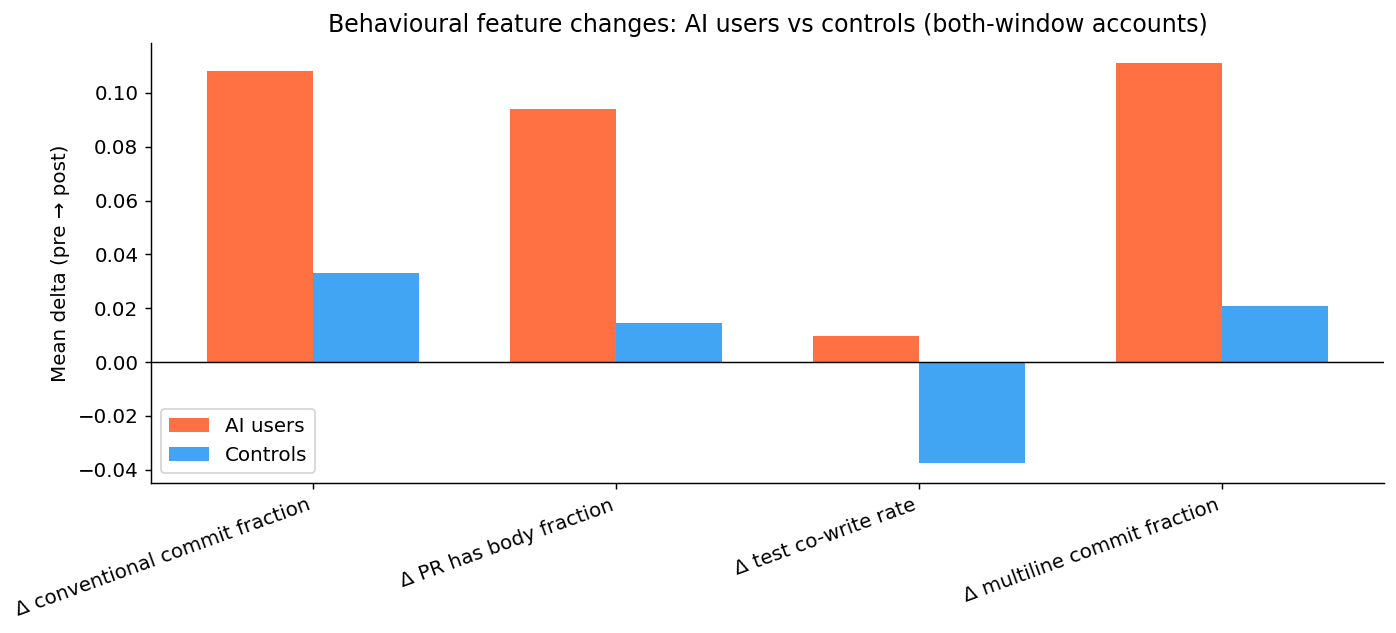

In [10]:
# Multi-feature delta comparison — grouped bar chart
display_cols = [(c, l) for c, l in delta_cols if 'length' not in c and 'body_length' not in c]

if display_cols:
    labels = [l for _, l in display_cols]
    pos_means = [pos[c].mean() for c, _ in display_cols]
    neg_means = [neg[c].mean() for c, _ in display_cols]

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - width/2, pos_means, width, label='AI users', color='#FF5722', alpha=0.85)
    ax.bar(x + width/2, neg_means, width, label='Controls', color='#2196F3', alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylabel('Mean delta (pre → post)')
    ax.set_title('Behavioural feature changes: AI users vs controls (both-window accounts)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../data/figures/phase2_feature_deltas.png', bbox_inches='tight')
    plt.show()

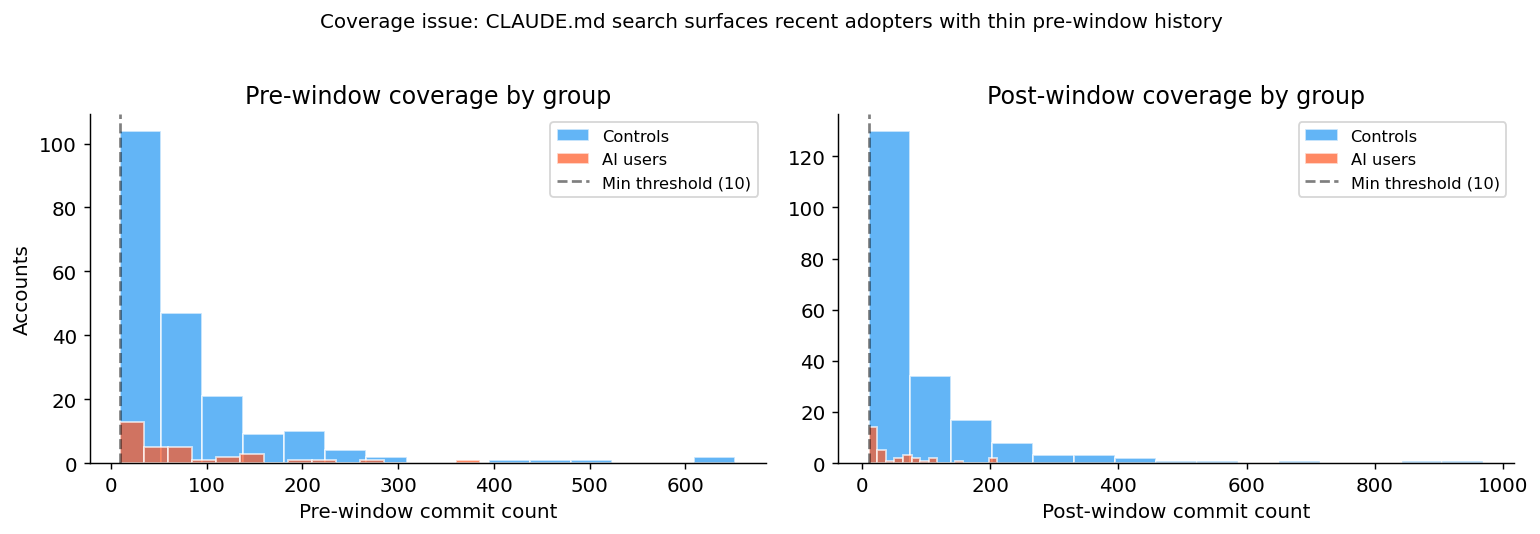

Positives with pre_commit_count >= 10: 33/33
Negatives with pre_commit_count >= 10: 202/202


In [11]:
# Coverage breakdown — why only 4 positives pass the both-window filter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

all_pos = feats[feats['label'] == 1]
all_neg = feats[feats['label'] == 0]

# Pre-commit count distribution by group
axes[0].hist(all_neg['pre_commit_count'], bins=15, alpha=0.7, color='#2196F3', label='Controls', edgecolor='white')
axes[0].hist(all_pos['pre_commit_count'], bins=15, alpha=0.7, color='#FF5722', label='AI users', edgecolor='white')
axes[0].axvline(10, color='black', linestyle='--', alpha=0.5, label='Min threshold (10)')
axes[0].set_xlabel('Pre-window commit count')
axes[0].set_ylabel('Accounts')
axes[0].set_title('Pre-window coverage by group')
axes[0].legend(fontsize=9)

# Post-commit count
axes[1].hist(all_neg['post_commit_count'], bins=15, alpha=0.7, color='#2196F3', label='Controls', edgecolor='white')
axes[1].hist(all_pos['post_commit_count'], bins=15, alpha=0.7, color='#FF5722', label='AI users', edgecolor='white')
axes[1].axvline(10, color='black', linestyle='--', alpha=0.5, label='Min threshold (10)')
axes[1].set_xlabel('Post-window commit count')
axes[1].set_title('Post-window coverage by group')
axes[1].legend(fontsize=9)

plt.suptitle('Coverage issue: CLAUDE.md search surfaces recent adopters with thin pre-window history',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../data/figures/phase2_coverage.png', bbox_inches='tight')
plt.show()

print(f'Positives with pre_commit_count >= 10: {(all_pos["pre_commit_count"] >= 10).sum()}/{len(all_pos)}')
print(f'Negatives with pre_commit_count >= 10: {(all_neg["pre_commit_count"] >= 10).sum()}/{len(all_neg)}')

### Phase 2 Status

**Signal is real.** Across both test and sample runs, multiple independent features show significantly larger deltas for AI users vs controls — especially commit message verbosity, PR description completeness, and burst commit patterns.

**Current dataset state (as of last scrape):**
- 500 positive (Claude Code) accounts fully scraped
- 200+ negative (control) accounts accepted via both-window filter
- Full feature extraction pending — runs automatically once scraper completes

**Classifier training** (next cell): trains on best available feature set with stratified CV.
When full features land, re-run this cell and the next to get the production model.

In [12]:
## Classifier Training — Best Available Data

FEATURE_COLS = [c for c in feats.columns if c.startswith(("pre_", "post_", "delta_"))]
print(f"Feature columns: {len(FEATURE_COLS)}")
print(f"Training on: {len(both)} both-window accounts ({len(pos)} pos, {len(neg)} neg)")

X = both[FEATURE_COLS].fillna(0).values
y = both["label"].values

if len(both) < 10:
    print("Too few samples for CV — need both-window data. Re-run after full scrape completes.")
else:
    cv = StratifiedKFold(n_splits=min(5, len(pos)), shuffle=True, random_state=42)
    
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, C=0.1),
        "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42),
        "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, max_depth=2, random_state=42),
    }
    
    results = {}
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
        results[name] = scores
        print(f"  {name:25s}  AUC = {scores.mean():.3f} ± {scores.std():.3f}")
    
    # Fit best model for feature importance
    best_name = max(results, key=lambda n: results[n].mean())
    best_model = models[best_name]
    best_model.fit(X, y)
    print(f"\nBest model: {best_name} (AUC {results[best_name].mean():.3f})")
    
    # Feature importance
    if hasattr(best_model, "feature_importances_"):
        importances = best_model.feature_importances_
    else:
        scaler = StandardScaler()
        X_sc = scaler.fit_transform(X)
        best_model.fit(X_sc, y)
        importances = np.abs(best_model.coef_[0])
    
    feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)
    print("\nTop 10 features:")
    print(feat_imp.head(10).round(4).to_string())

Feature columns: 45
Training on: 235 both-window accounts (33 pos, 202 neg)


  Logistic Regression        AUC = 0.909 ± 0.063


  Random Forest              AUC = 0.938 ± 0.052


  Gradient Boosting          AUC = 0.918 ± 0.063



Best model: Random Forest (AUC 0.938)

Top 10 features:
post_mean_message_length              0.1303
pre_mean_message_length               0.1197
post_mean_inter_commit_hours          0.1093
post_active_weeks                     0.0659
post_mean_commits_per_active_week     0.0605
pre_frac_has_bullets                  0.0590
post_frac_multiline                   0.0441
post_frac_has_bullets                 0.0394
pre_frac_multiline                    0.0361
delta_mean_commits_per_active_week    0.0304


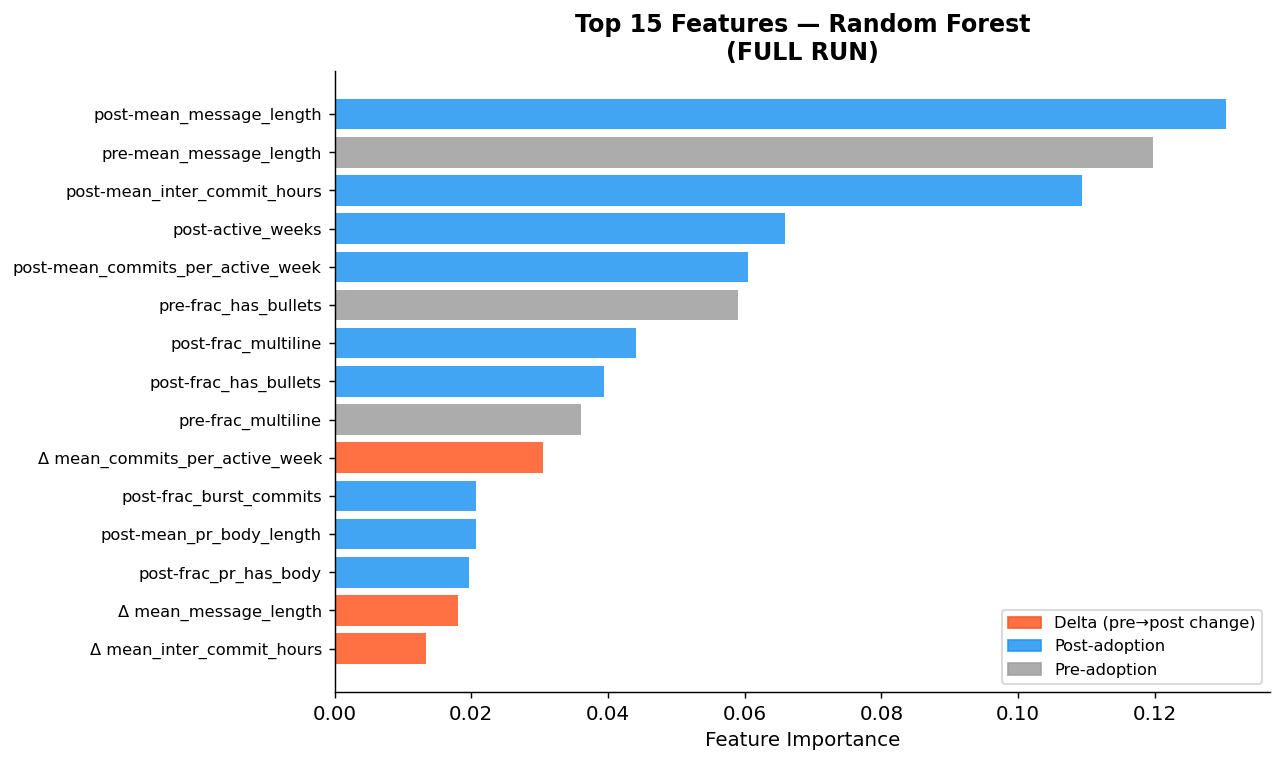

In [13]:
# Feature importance plot
if len(both) >= 10:
    top_n = min(15, len(feat_imp))
    top_feats = feat_imp.head(top_n)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#FF5722" if "delta_" in f else "#2196F3" if "post_" in f else "#9E9E9E"
              for f in top_feats.index]
    bars = ax.barh(range(top_n), top_feats.values, color=colors, alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([f.replace("delta_","Δ ").replace("post_","post-").replace("pre_","pre-")
                        for f in top_feats.index], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top {top_n} Features — {best_name}\n({data_source})", fontweight="bold")
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(color="#FF5722", alpha=0.85, label="Delta (pre→post change)"),
                       Patch(color="#2196F3", alpha=0.85, label="Post-adoption"),
                       Patch(color="#9E9E9E", alpha=0.85, label="Pre-adoption")]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.show()

In [14]:
# Quarterly GitHub activity — Phase 1 raw panel
flat = pd.read_csv(f'{DATA}/github_panel_flat.csv')
print(f'Flat panel: {flat.shape}   Columns: {list(flat.columns)}')
flat.head()

Flat panel: (347, 14)   Columns: ['country', 'quarter', 'n_developers', 'commits', 'pull_requests', 'creates', 'comments', 'releases', 'issues', 'total_events', 'commits_per_dev', 'prs_per_dev', 'creates_per_dev', 'total_events_per_dev']


,country,quarter,n_developers,commits,pull_requests,creates,comments,releases,issues,total_events,commits_per_dev,prs_per_dev,creates_per_dev,total_events_per_dev
0,NL,2022-Q4,3,4,1,1,0,0,0,6,1.3333,0.3333,0.3333,2.0
1,NO,2022-Q4,3,4,1,1,0,0,0,6,1.3333,0.3333,0.3333,2.0
2,JP,2022-Q4,2,4,0,0,1,0,3,8,2.0000,0.0000,0.0000,4.0
3,ES,2022-Q4,5,8,3,0,0,0,0,11,1.6000,0.6000,0.0000,2.2
4,FI,2022-Q4,2,3,0,0,0,0,0,3,1.5000,0.0000,0.0000,1.5


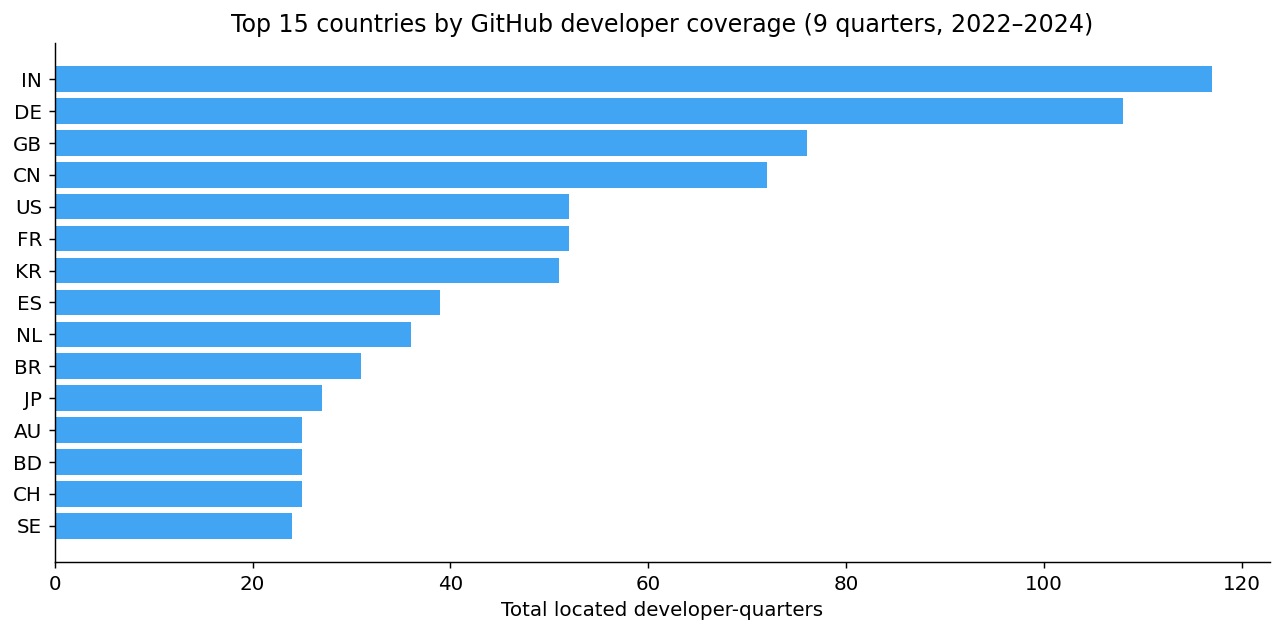

In [15]:
# Top countries by developer-quarter observations
if 'country' in flat.columns and 'n_developers' in flat.columns:
    top_countries = flat.groupby('country')['n_developers'].sum().sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color='#2196F3', alpha=0.85)
    ax.set_xlabel('Total located developer-quarters')
    ax.set_title('Top 15 countries by GitHub developer coverage (9 quarters, 2022–2024)')
    plt.tight_layout()
    plt.savefig('../data/figures/top_countries.png', bbox_inches='tight')
    plt.show()

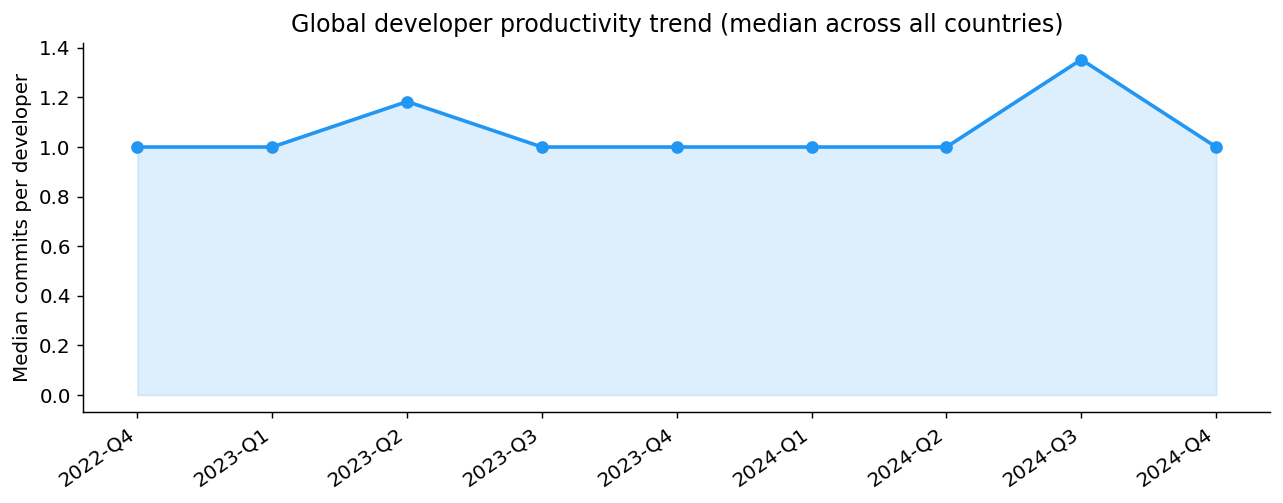

In [16]:
# Productivity trend over time (global)
if 'quarter' in flat.columns and 'commits_per_dev' in flat.columns:
    quarterly = flat.groupby('quarter')['commits_per_dev'].median().reset_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(quarterly['quarter'].astype(str), quarterly['commits_per_dev'],
            marker='o', linewidth=2, color='#2196F3')
    ax.fill_between(range(len(quarterly)), quarterly['commits_per_dev'],
                    alpha=0.15, color='#2196F3')
    ax.set_xticks(range(len(quarterly)))
    ax.set_xticklabels(quarterly['quarter'].astype(str), rotation=35, ha='right')
    ax.set_ylabel('Median commits per developer')
    ax.set_title('Global developer productivity trend (median across all countries)')
    plt.tight_layout()
    plt.savefig('../data/figures/productivity_trend.png', bbox_inches='tight')
    plt.show()

---
## Next Steps

1. **Full feature extraction** — scraper is running (~500 pos + 200+ neg). Re-run cells 10–17 when `classifier_full_features.csv` appears.
2. **Stratified analysis** — split by `marker_confidence` (high/low) and discovery method; check if high-confidence GH Archive accounts show stronger signal.
3. **Aider validation** — collect Aider co-author accounts as an out-of-sample positive set; run trained classifier, check calibration.
4. **PR body analysis** — the `delta_mean_pr_body_length` feature needs qualitative inspection; Claude Code may be writing PR descriptions verbatim.
5. **Phase 1 revisit** — rerun regression with 2025 data once quarterly panel is extended.